In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the results
#df_sender = pd.read_csv("statistics.csv")
#df_receiver = pd.read_csv("receiver_statistics.csv")


#C:\Users\YSJCOMP\Documents\Publications\! based on PhD\LoRa and encryption Brief Report\code\Results\Results_1\Statistics

#df_sender = pd.read_csv("./Results_6/Statistics/statistics.csv")
#df_receiver = pd.read_csv("./Results_6/receiver_statistics.csv")

df_sender = pd.read_csv("./Results_backwords_1/Statistics/statistics.csv")
df_receiver = pd.read_csv("./Results_backwords_1/receiver_statistics.csv")

In [3]:
df_sender.head()

,Method,File_name,File_size,Chunks_sent,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1032,5,9.08,2.81,9.52,3.86
1,CRYSTALS-Kyber,0001t,768,4,0.00,0.00,0.00,0.00
2,CRYSTALS-Kyber,0002q,1032,5,9.04,2.69,8.92,3.68
3,CRYSTALS-Kyber,0002t,768,4,0.00,0.00,0.00,0.00
4,CRYSTALS-Kyber,0003q,1032,5,9.04,2.68,9.40,3.82


In [4]:
df_receiver.head()

,flag,received_chunks
0,0001q,3
1,0001t,4
2,0002q,5
3,0002t,4
4,0003q,5


In [5]:
# "flag" in the receiver_statistics.csv the same as File_name in the statistics.csv
df_receiver = df_receiver.rename(columns={"flag": "File_name"})

In [6]:
df_receiver.head()

,File_name,received_chunks
0,0001q,3
1,0001t,4
2,0002q,5
3,0002t,4
4,0003q,5


In [7]:
# Merge the results in one df
df = pd.merge(df_sender, df_receiver,
              on="File_name",
              how="left"
)


In [8]:
# Placed Chunks_sent and received_chunks together
ordered_columns = [
    "Method",
    "File_name",
    "File_size",
    "Chunks_sent",
    "received_chunks",   # ← moved received_chunks
    "Transmission_time",
    "Energy_for_transmission",
    "Compression_encryption_time",
    "Energy_for_compression_encryption"
]

df = df[ordered_columns]


In [9]:
df.head()

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1032,5,3,9.08,2.81,9.52,3.86
1,CRYSTALS-Kyber,0001t,768,4,4,0.00,0.00,0.00,0.00
2,CRYSTALS-Kyber,0002q,1032,5,5,9.04,2.69,8.92,3.68
3,CRYSTALS-Kyber,0002t,768,4,4,0.00,0.00,0.00,0.00
4,CRYSTALS-Kyber,0003q,1032,5,5,9.04,2.68,9.40,3.82


#### Check if all sent chunks were received

In [10]:
# check if all sent chunks were received
are_equal = df['Chunks_sent'].equals(df['received_chunks'])
are_equal

False

In [11]:
# Compare the two columns element
comparison = df['Chunks_sent'] == df['received_chunks']

# Check through each element
for i, is_equal in enumerate(comparison):
    if not is_equal:
        print(f"Row {i} mismatch: Method={df.loc[i, 'Method']}, File name - {df.loc[i, 'File_name']}, Chunks_sent={df.loc[i, 'Chunks_sent']}, received_chunks={df.loc[i, 'received_chunks']}")

Row 0 mismatch: Method=CRYSTALS-Kyber, File name - 0001q, Chunks_sent=5, received_chunks=3


#### Remove the cipher text
<i>as it was needed to check if all chunk in cipher text file were received. All metrics were written in the encrypted file rows.</i>

In [12]:
# Extract the numeric part of File_name (e.g., '0217' from '0217q', '0217t')
df["num_key_temp"] = df["File_name"].astype(str).str.extract(r"(\d+)", expand=False)

In [13]:
# Compute total File_size per numeric key (sum across q/t/others)
size_sum = (
    df.groupby("num_key_temp", as_index=False)["File_size"]
      .sum()
      .rename(columns={"File_size": "File_size_total_temp"})
)

In [14]:
# Map the total size to all rows: Group "0217" → rows: 0217q, 0217t
df = df.merge(size_sum, on="num_key_temp", how="left")

In [15]:
# Remove rows that have 't' in the File_name (case-insensitive) 
df = df[~df["File_name"].str.lower().str.contains("t")].copy()

In [16]:
# Overwrite File_size with the summed total for the numeric group
df.loc[:, "File_size"] = df["File_size_total_temp"]

In [17]:
# Clean up temp columns
df = df.drop(columns=["num_key_temp", "File_size_total_temp"])

In [18]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76
...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74


#### Adding additional performance metrics

<i>Encryption overhead (%)</i>

In [19]:
# Get unencrypted compressed size values
vae_size = df.loc[df['Method'] == 'VAE', 'File_size'].reset_index(drop=True)

In [20]:
# Create a temp helper column for unencrypted compressed size values
df['VAE_size_temp'] = 0.0

In [21]:
# Write unencrypted compressed size values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'VAE_size_temp'] = vae_size.values

In [22]:
# Creat a column for Encryption overhead size values
df['Encryption_overhead'] = 0.0

In [23]:
# Fill the Encryption overhead and round the values
df['Encryption_overhead'] = ((df['File_size'] - df['VAE_size_temp']) / df['VAE_size_temp']) * 100
df['Encryption_overhead'] = df['Encryption_overhead'].round(2)

In [24]:
# Clean up temp column column
df = df.drop(columns=["VAE_size_temp"])

In [25]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26
...,...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.00
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.00
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.00
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.00


<i>Airtime overhead (%)</i>

In [26]:
# Get unencrypted Transmission time values
vae_Transmission_time = df.loc[df['Method'] == 'VAE', 'Transmission_time'].reset_index(drop=True)

In [27]:
# Create a temp helper column for unencrypted Transmission time values
df['VAE_Transmission_time_temp'] = 0.0

In [28]:
# Write unencrypted Transmission time values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'VAE_Transmission_time_temp'] = vae_Transmission_time.values

In [29]:
# Creat a column for Airtime overhead size values
df['Airtime_overhead'] = 0.0

In [30]:
# Fill the Encryption overhead and round the values
df['Airtime_overhead'] = ((df['Transmission_time'] - df['VAE_Transmission_time_temp']) / df['VAE_Transmission_time_temp']) * 100
df['Airtime_overhead'] = df['Airtime_overhead'].round(2)

In [31]:
# Clean up temp column column
df = df.drop(columns=['VAE_Transmission_time_temp'])

In [32]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17,80.88
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17,80.08
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17,80.08
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34,80.08
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26,80.08
...,...,...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.00,0.00
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.00,0.00
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.00,0.00
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.00,0.00


<i>Energy for transmission overhead</i>

In [33]:
# Get unencrypted Energy for transmission values
vae_Energy_for_transmission = df.loc[df['Method'] == 'VAE', 'Energy_for_transmission'].reset_index(drop=True)

In [34]:
# Create a temp helper column for unencrypted Energy for transmission values
df['Energy_for_transmission_temp'] = 0.0

In [35]:
# Write unencrypted Energy for transmission values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'Energy_for_transmission_temp'] = vae_Energy_for_transmission.values

In [36]:
# Creat a column for Airtime overhead size values
df['Energy_transmission_overhead'] = 0.0

In [37]:
# Fill the Encryption overhead and round the values
df['Energy_transmission_overhead'] = ((df['Energy_for_transmission'] - df['Energy_for_transmission_temp']) / df['Energy_for_transmission_temp']) * 100
df['Energy_transmission_overhead'] = df['Energy_transmission_overhead'].round(2)

In [38]:
# Clean up temp column column
df = df.drop(columns=['Energy_for_transmission_temp'])

In [39]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17,80.88,88.59
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17,80.08,78.15
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17,80.08,78.67
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34,80.08,78.29
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26,80.08,80.13
...,...,...,...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.00,0.00,0.00
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.00,0.00,0.00
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.00,0.00,0.00
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.00,0.00,0.00


<i>Energy for encryption overhead</i>

In [40]:
# Get unencrypted Energy for encryption values
vae_Energy_for_compression_encryption = df.loc[df['Method'] == 'VAE', 'Energy_for_compression_encryption'].reset_index(drop=True)

In [41]:
# Create a temp helper column for unencrypted Energy for encryption values
df['Energy_for_encryption_temp'] = 0.0

In [42]:
# Write unencrypted Energy for encryption values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'Energy_for_encryption_temp'] = vae_Energy_for_compression_encryption.values

In [43]:
# Creat a column for Airtime overhead size values
df['Energy_encryption_overhead'] = 0.0

In [44]:
# Fill the Encryption overhead and round the values
df['Energy_encryption_overhead'] = ((df['Energy_for_compression_encryption'] - df['Energy_for_encryption_temp']) / df['Energy_for_encryption_temp']) * 100
df['Energy_encryption_overhead'] = df['Energy_encryption_overhead'].round(2)

In [45]:
# Clean up temp column column
df = df.drop(columns=['Energy_for_encryption_temp'])

In [46]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead,Energy_encryption_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17,80.88,88.59,-2.03
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17,80.08,78.15,-1.60
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17,80.08,78.67,1.33
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34,80.08,78.29,-4.97
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26,80.08,80.13,2.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.00,0.00,0.00,0.00
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.00,0.00,0.00,0.00
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.00,0.00,0.00,0.00
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.00,0.00,0.00,0.00


## Results Graphs

##### Payload Size, Fragmentation, and Reliability

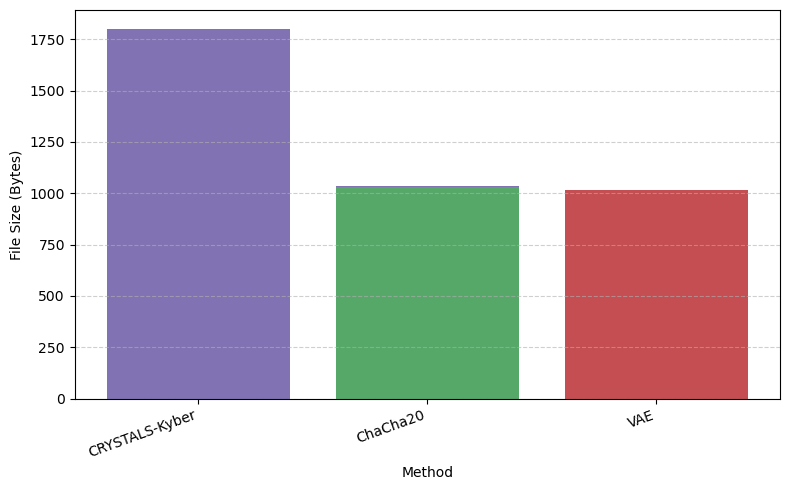

In [47]:
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["File_size"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("File Size (Bytes)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

#### Compression and Encryption Processing

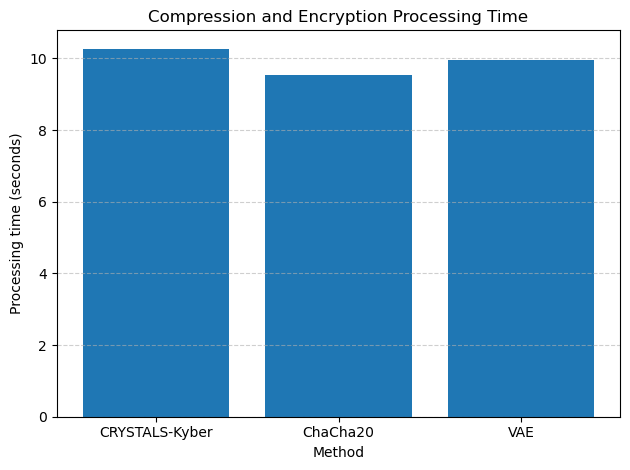

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Method"], df["Compression_encryption_time"])
plt.xlabel("Method")
plt.ylabel("Processing time (seconds)")
plt.title("Compression and Encryption Processing Time")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


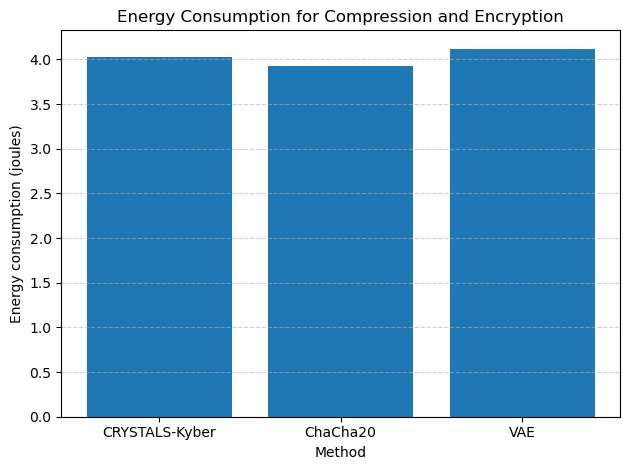

In [49]:
plt.figure()
plt.bar(df["Method"], df["Energy_for_compression_encryption"])
plt.xlabel("Method")
plt.ylabel("Energy consumption (joules)")
plt.title("Energy Consumption for Compression and Encryption")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


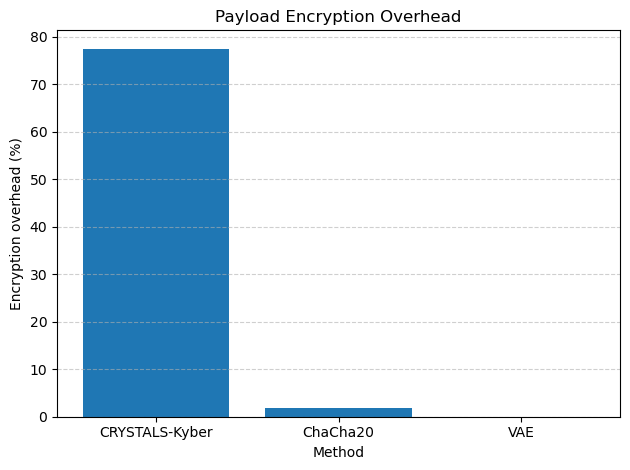

In [50]:
plt.figure()
plt.bar(df["Method"], df["Encryption_overhead"])
plt.xlabel("Method")
plt.ylabel("Encryption overhead (%)")
plt.title("Payload Encryption Overhead")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


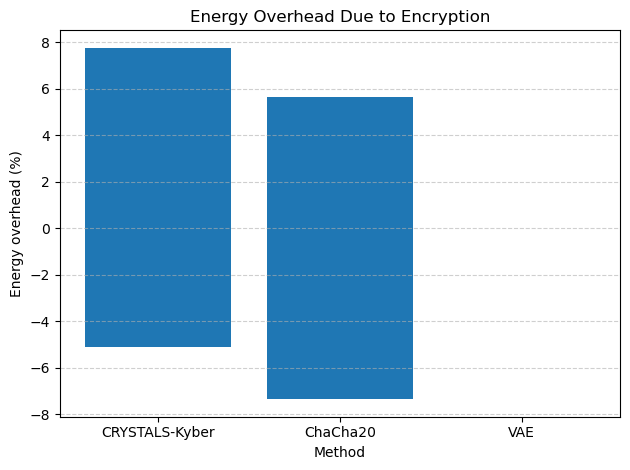

In [51]:
plt.figure()
plt.bar(df["Method"], df["Energy_encryption_overhead"])
plt.xlabel("Method")
plt.ylabel("Energy overhead (%)")
plt.title("Energy Overhead Due to Encryption")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [53]:
'''measures = ['Compression_encryption_time', 'Energy_for_compression_encryption',
            'Encryption_overhead', 'Energy_encryption_overhead']

for measure in measures:
    plt.figure(figsize=(8,5))
    bars = plt.bar(df['Method'], df[measure], color=['skyblue', 'orange', 'green'])
    plt.title(f'{measure} per Method')
    plt.ylabel(measure)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')
    
    plt.show()
'''

"measures = ['Compression_encryption_time', 'Energy_for_compression_encryption',\n            'Encryption_overhead', 'Energy_encryption_overhead']\n\nfor measure in measures:\n    plt.figure(figsize=(8,5))\n    bars = plt.bar(df['Method'], df[measure], color=['skyblue', 'orange', 'green'])\n    plt.title(f'{measure} per Method')\n    plt.ylabel(measure)\n    \n    # Add value labels on top of bars\n    for bar in bars:\n        height = bar.get_height()\n        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')\n    \n    plt.show()\n"

In [54]:
'''df_delta = df.copy()
for measure in measures:
    df_delta[measure + '_change'] = df[measure].diff().fillna(0)
'''

"df_delta = df.copy()\nfor measure in measures:\n    df_delta[measure + '_change'] = df[measure].diff().fillna(0)\n"

In [55]:
'''for measure in measures:
    plt.figure(figsize=(8,5))
    bars = plt.bar(df['Method'], df_delta[measure + '_change'], color=['skyblue', 'orange', 'green'])
    plt.title(f'Change in {measure} from previous method')
    plt.ylabel('Change')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')
    
    plt.show()
'''

"for measure in measures:\n    plt.figure(figsize=(8,5))\n    bars = plt.bar(df['Method'], df_delta[measure + '_change'], color=['skyblue', 'orange', 'green'])\n    plt.title(f'Change in {measure} from previous method')\n    plt.ylabel('Change')\n    \n    # Add value labels\n    for bar in bars:\n        height = bar.get_height()\n        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')\n    \n    plt.show()\n"

In [56]:
'''df_temp = pd.DataFrame({
    'Method': ['VAE', 'ChaCha20', 'CRYSTALS-Kyber', 'VAE', 'ChaCha20', 'CRYSTALS-Kyber', 
               'VAE', 'ChaCha20', 'CRYSTALS-Kyber', 'VAE', 'ChaCha20'],
    'Compression_encryption_time': [100, 120, 140, 124, 152, 138, 138, 140, 152, 145, 125],
    'Energy_for_compression_encryption': [10, 12, 14, 12, 15, 13, 13, 14, 15, 14, 12],
    'Encryption_overhead': [0.100, 0.120, 0.140, 0.124, 0.152, 0.138, 0.138, 0.140, 0.152, 0.145, 0.125],
    'Energy_encryption_overhead': [10, 12, 14, 12, 15, 13, 13, 14, 15, 14, 12]
})

df_temp
'''

"df_temp = pd.DataFrame({\n    'Method': ['VAE', 'ChaCha20', 'CRYSTALS-Kyber', 'VAE', 'ChaCha20', 'CRYSTALS-Kyber', \n               'VAE', 'ChaCha20', 'CRYSTALS-Kyber', 'VAE', 'ChaCha20'],\n    'Compression_encryption_time': [100, 120, 140, 124, 152, 138, 138, 140, 152, 145, 125],\n    'Energy_for_compression_encryption': [10, 12, 14, 12, 15, 13, 13, 14, 15, 14, 12],\n    'Encryption_overhead': [0.100, 0.120, 0.140, 0.124, 0.152, 0.138, 0.138, 0.140, 0.152, 0.145, 0.125],\n    'Energy_encryption_overhead': [10, 12, 14, 12, 15, 13, 13, 14, 15, 14, 12]\n})\n\ndf_temp\n"

In [57]:
'''import matplotlib.pyplot as plt

measure = 'Compression_encryption_time'

# Choose one color per method
colors = ['skyblue', 'orange', 'green']

plt.figure(figsize=(8,5))
bars = plt.bar(df['Method'], df[measure], color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.title(f'{measure} per Method')
plt.ylabel(measure)
plt.show()
'''

"import matplotlib.pyplot as plt\n\nmeasure = 'Compression_encryption_time'\n\n# Choose one color per method\ncolors = ['skyblue', 'orange', 'green']\n\nplt.figure(figsize=(8,5))\nbars = plt.bar(df['Method'], df[measure], color=colors)\n\n# Add value labels on top of bars\nfor bar in bars:\n    height = bar.get_height()\n    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')\n\nplt.title(f'{measure} per Method')\nplt.ylabel(measure)\nplt.show()\n"

In [58]:
'''import matplotlib.pyplot as plt

# Filter for VAE method
vae_df = df[df['Method'] == 'VAE']

# Choose the measures you want to plot
measures = ['Compression_encryption_time', 
            'Energy_for_compression_encryption',
            'Encryption_overhead',
            'Energy_encryption_overhead']

# Extract the values for VAE
vae_values = vae_df[measures].values.flatten()

# Plot line graph
plt.figure(figsize=(8,5))
plt.plot(measures, vae_values, marker='o', linestyle='-', color='blue', linewidth=2)
plt.title('VAE Method Measures')
plt.ylabel('Value')
plt.xticks(rotation=15)
plt.grid(True)

# Add value labels on each point
for i, val in enumerate(vae_values):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')

plt.show()
'''

"import matplotlib.pyplot as plt\n\n# Filter for VAE method\nvae_df = df[df['Method'] == 'VAE']\n\n# Choose the measures you want to plot\nmeasures = ['Compression_encryption_time', \n            'Energy_for_compression_encryption',\n            'Encryption_overhead',\n            'Energy_encryption_overhead']\n\n# Extract the values for VAE\nvae_values = vae_df[measures].values.flatten()\n\n# Plot line graph\nplt.figure(figsize=(8,5))\nplt.plot(measures, vae_values, marker='o', linestyle='-', color='blue', linewidth=2)\nplt.title('VAE Method Measures')\nplt.ylabel('Value')\nplt.xticks(rotation=15)\nplt.grid(True)\n\n# Add value labels on each point\nfor i, val in enumerate(vae_values):\n    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')\n\nplt.show()\n"

In [59]:
#stoppppp

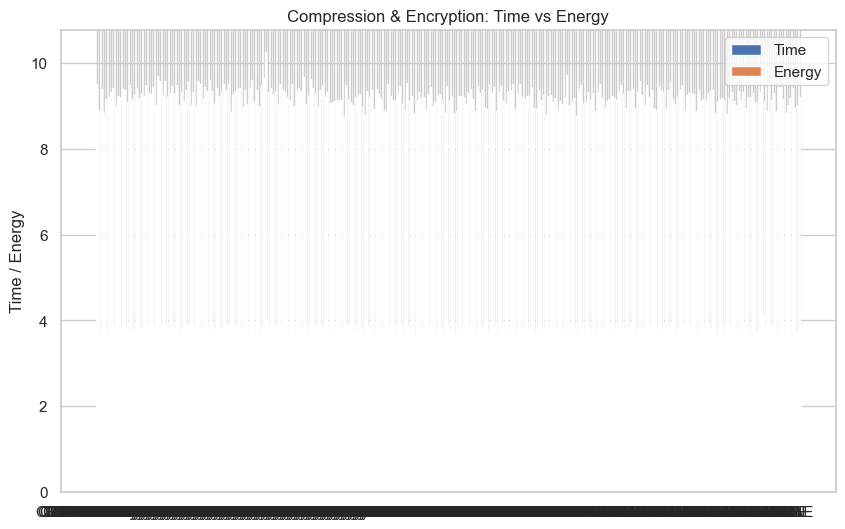

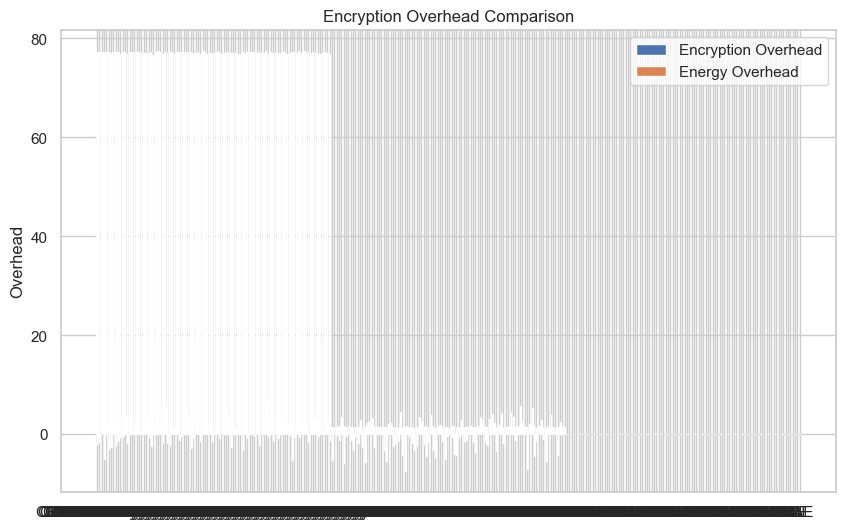

In [60]:
# Set plot style
sns.set(style="whitegrid")

# Plot 1: Compression vs Energy for compression/encryption
fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.35
x = range(len(df))

ax.bar(x, df['Compression_encryption_time'], width=bar_width, label='Time')
ax.bar([i + bar_width for i in x], df['Energy_for_compression_encryption'], width=bar_width, label='Energy')

ax.set_xticks([i + bar_width/2 for i in x])
ax.set_xticklabels(df['Method'])
ax.set_ylabel('Time / Energy')
ax.set_title('Compression & Encryption: Time vs Energy')
ax.legend()
plt.show()

# Plot 2: Encryption overheads
fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.35

ax.bar(x, df['Encryption_overhead'], width=bar_width, label='Encryption Overhead')
ax.bar([i + bar_width for i in x], df['Energy_encryption_overhead'], width=bar_width, label='Energy Overhead')

ax.set_xticks([i + bar_width/2 for i in x])
ax.set_xticklabels(df['Method'])
ax.set_ylabel('Overhead')
ax.set_title('Encryption Overhead Comparison')
ax.legend()
plt.show()

In [61]:
'''import pandas as pd
import matplotlib.pyplot as plt



metrics = ['Compression_encryption_time', 'Energy_for_compression_encryption',
           'Encryption_overhead', 'Energy_encryption_overhead']

plt.figure(figsize=(10,6))

# Plot each metric as a line
for metric in metrics:
    plt.plot(df['Method'], df[metric], marker='o', label=metric)

plt.title('Metrics Comparison by Method')
plt.xlabel('Method')
plt.ylabel('Value')
plt.ylim(0, max(df[metrics].max())*1.2)  # optional: give some headroom
plt.legend()
plt.grid(True)
plt.show()
'''

"import pandas as pd\nimport matplotlib.pyplot as plt\n\n\n\nmetrics = ['Compression_encryption_time', 'Energy_for_compression_encryption',\n           'Encryption_overhead', 'Energy_encryption_overhead']\n\nplt.figure(figsize=(10,6))\n\n# Plot each metric as a line\nfor metric in metrics:\n    plt.plot(df['Method'], df[metric], marker='o', label=metric)\n\nplt.title('Metrics Comparison by Method')\nplt.xlabel('Method')\nplt.ylabel('Value')\nplt.ylim(0, max(df[metrics].max())*1.2)  # optional: give some headroom\nplt.legend()\nplt.grid(True)\nplt.show()\n"

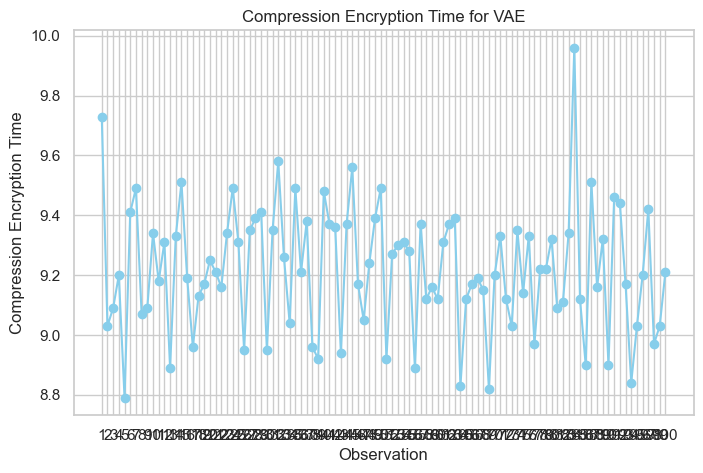

In [62]:
# Filter only VAE
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)

# Plot Compression_encryption_time for VAE
plt.figure(figsize=(8,5))
plt.plot(vae_df.index + 1, vae_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue')
plt.title('Compression Encryption Time for VAE')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.xticks(vae_df.index + 1)
plt.grid(True)
plt.show()

In [63]:
vae_df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead,Energy_encryption_overhead
0,VAE,0201v,1016,5,5,5.02,1.49,9.73,3.94,0.0,0.0,0.0,0.0
1,VAE,0202v,1016,5,5,5.02,1.51,9.03,3.74,0.0,0.0,0.0,0.0
2,VAE,0203v,1016,5,5,5.02,1.50,9.09,3.77,0.0,0.0,0.0,0.0
3,VAE,0204v,1015,5,5,5.02,1.52,9.20,3.82,0.0,0.0,0.0,0.0
4,VAE,0205v,1016,5,5,5.02,1.51,8.79,3.67,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.0,0.0,0.0,0.0
96,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.0,0.0,0.0,0.0
97,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.0,0.0,0.0,0.0
98,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.0,0.0,0.0,0.0


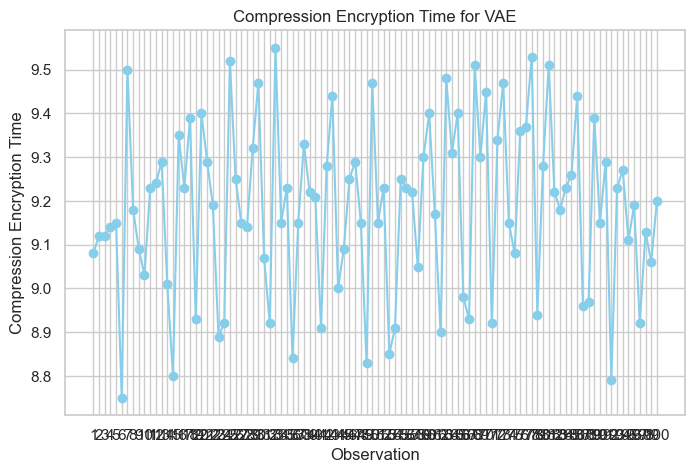

In [64]:
# Filter only ChaCha20
ChaCha20_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)

# Plot Compression_encryption_time for VAE
plt.figure(figsize=(8,5))
plt.plot(ChaCha20_df.index + 1, ChaCha20_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue')
plt.title('Compression Encryption Time for VAE')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.xticks(ChaCha20_df.index + 1)
plt.grid(True)
plt.show()

In [65]:
ChaCha20_df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead,Energy_encryption_overhead
0,ChaCha20,0101c,1031,5,5,5.02,1.51,9.08,3.74,1.48,0.0,1.34,-5.08
1,ChaCha20,0102c,1032,5,5,5.02,1.51,9.12,3.75,1.57,0.0,0.00,0.27
2,ChaCha20,0103c,1032,5,5,5.02,1.49,9.12,3.76,1.57,0.0,-0.67,-0.27
3,ChaCha20,0104c,1032,5,5,5.02,1.50,9.14,3.78,1.67,0.0,-1.32,-1.05
4,ChaCha20,0105c,1033,5,5,5.02,1.52,9.15,3.80,1.67,0.0,0.66,3.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ChaCha20,0196c,1030,5,5,5.03,1.52,9.19,3.83,1.28,0.0,1.33,0.79
96,ChaCha20,0197c,1032,5,5,5.03,1.52,8.92,3.70,1.57,0.0,1.33,-4.39
97,ChaCha20,0198c,1031,5,5,5.02,1.50,9.13,3.82,1.58,-0.2,-1.32,2.41
98,ChaCha20,0199c,1033,5,5,5.03,1.52,9.06,3.76,1.67,0.0,0.00,0.53


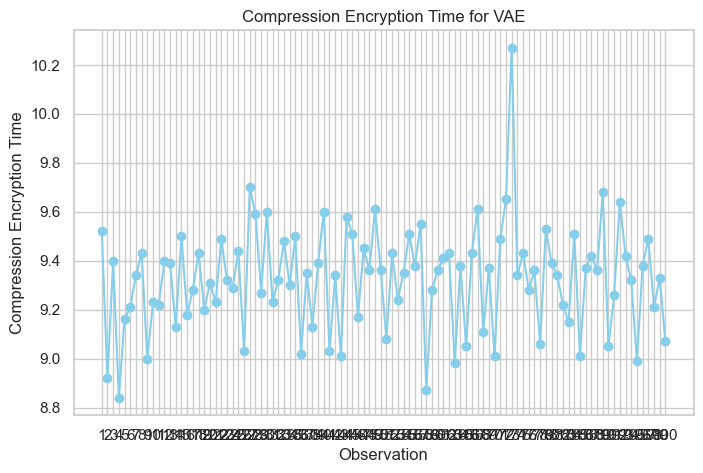

In [66]:
# Filter only CRYSTALS-Kyber
CRYSTALS_Kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

# Plot Compression_encryption_time for VAE
plt.figure(figsize=(8,5))
plt.plot(CRYSTALS_Kyber_df.index + 1, CRYSTALS_Kyber_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue')
plt.title('Compression Encryption Time for VAE')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.xticks(CRYSTALS_Kyber_df.index + 1)
plt.grid(True)
plt.show()

In [67]:
CRYSTALS_Kyber_df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead,Energy_encryption_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17,80.88,88.59,-2.03
1,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17,80.08,78.15,-1.60
2,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17,80.08,78.67,1.33
3,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34,80.08,78.29,-4.97
4,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26,80.08,80.13,2.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CRYSTALS-Kyber,0096q,1799,5,5,9.04,2.72,9.38,3.86,76.89,79.72,81.33,1.58
96,CRYSTALS-Kyber,0097q,1800,5,5,9.05,2.71,9.49,3.89,77.17,79.92,80.67,0.52
97,CRYSTALS-Kyber,0098q,1800,5,5,9.05,2.74,9.21,3.81,77.34,79.92,80.26,2.14
98,CRYSTALS-Kyber,0099q,1799,5,5,9.04,2.72,9.33,3.84,77.07,79.72,78.95,2.67


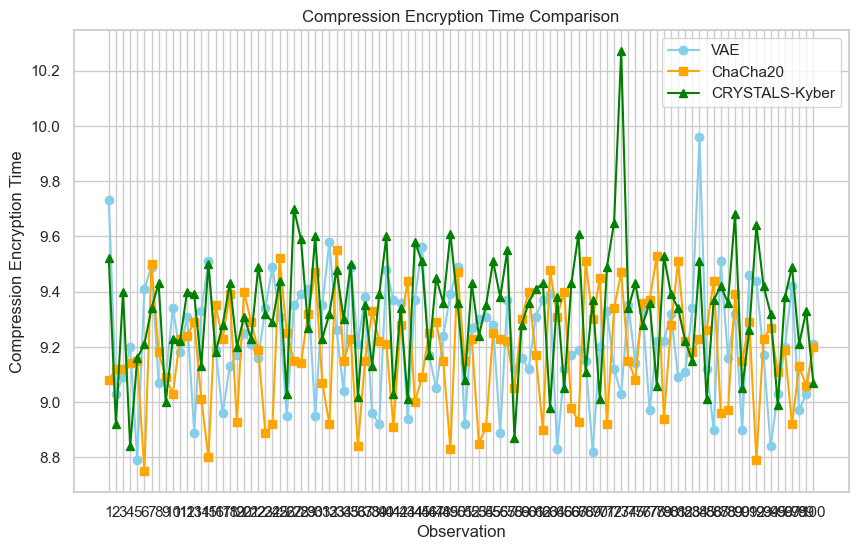

In [68]:


# Filter each method
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method with different colors and labels
plt.plot(vae_df.index + 1, vae_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Compression_encryption_time'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Compression_encryption_time'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize the plot
plt.title('Compression Encryption Time Comparison')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.xticks(range(1, max(len(vae_df), len(chacha_df), len(kyber_df)) + 1))
plt.grid(True)
plt.legend()
plt.show()


In [69]:


# Group by Method and calculate mean and median
summary = df.groupby('Method')['Compression_encryption_time'].agg(['mean', 'median']).reset_index()

summary


,Method,mean,median
0,CRYSTALS-Kyber,9.3264,9.350
1,ChaCha20,9.1851,9.205
2,VAE,9.2183,9.210


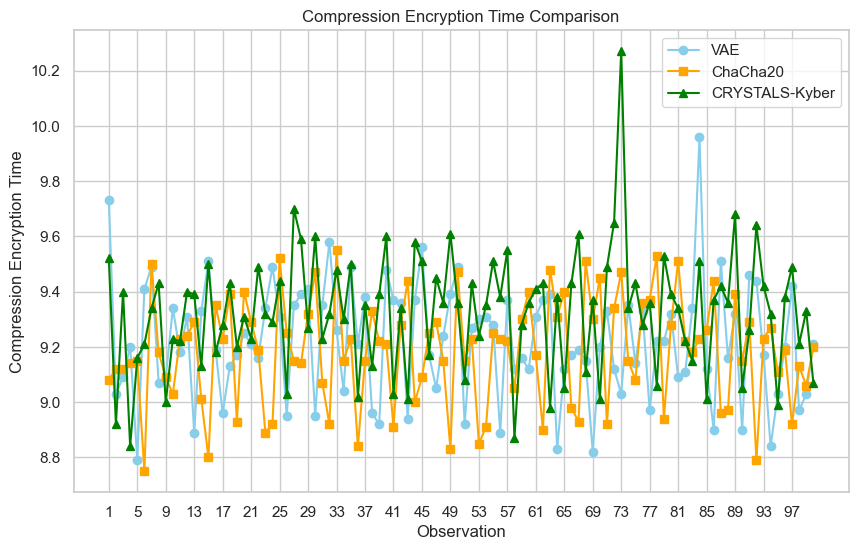

In [70]:
import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Compression_encryption_time'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Compression_encryption_time'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis: show every 4th observation
max_obs = max(len(vae_df), len(chacha_df), len(kyber_df))
plt.xticks(range(1, max_obs + 1, 4))  # step=4

# Add labels, legend, grid
plt.title('Compression Encryption Time Comparison')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.grid(True)
plt.legend()
plt.show()


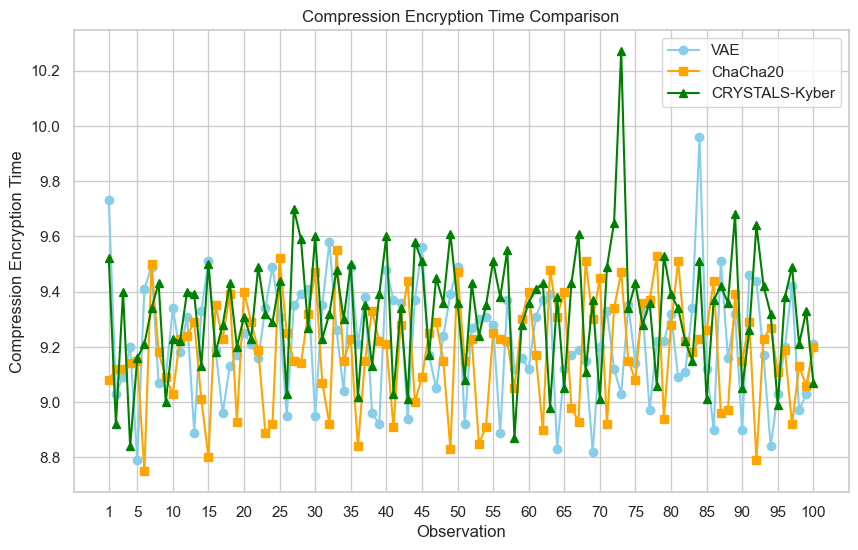

In [71]:


# Filter each method
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Compression_encryption_time'], marker='o', linestyle='-', color='skyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Compression_encryption_time'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Compression_encryption_time'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis to show specific ticks
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Add labels, legend, grid
plt.title('Compression Encryption Time Comparison')
plt.xlabel('Observation')
plt.ylabel('Compression Encryption Time')
plt.grid(True)
plt.legend()
plt.show()


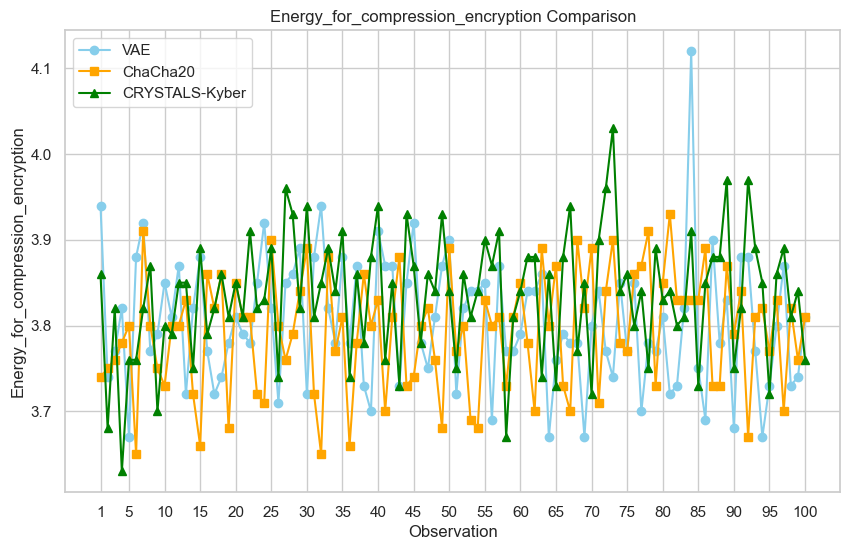

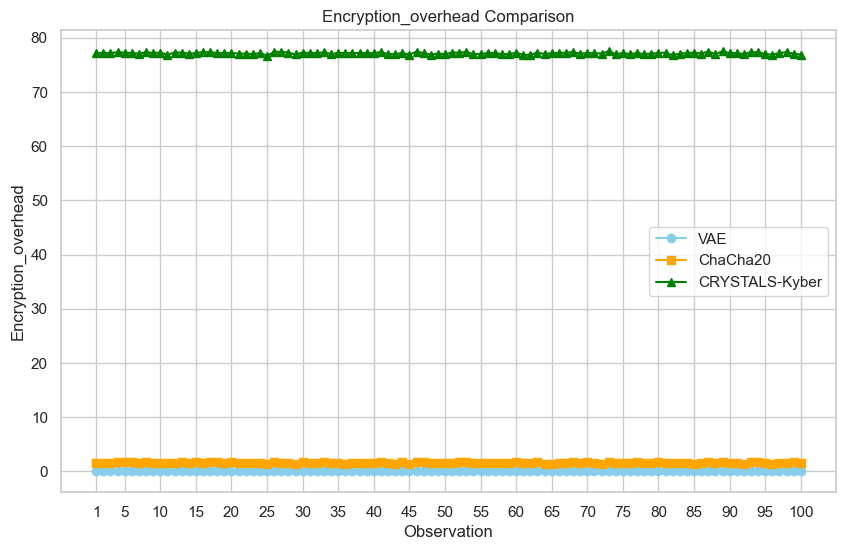

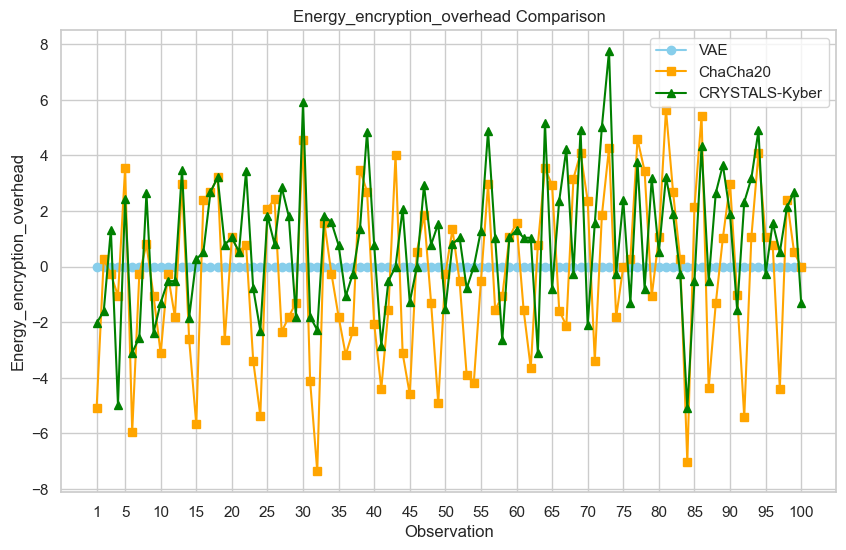

In [72]:


columns = ['Energy_for_compression_encryption', 'Encryption_overhead', 'Energy_encryption_overhead']
colors = {'VAE': 'skyblue', 'ChaCha20': 'orange', 'CRYSTALS-Kyber': 'green'}
markers = {'VAE': 'o', 'ChaCha20': 's', 'CRYSTALS-Kyber': '^'}

# Filter each method
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

for col in columns:
    plt.figure(figsize=(10,6))
    
    # Plot each method for the current column
    plt.plot(vae_df.index + 1, vae_df[col], marker=markers['VAE'], linestyle='-', color=colors['VAE'], label='VAE')
    plt.plot(chacha_df.index + 1, chacha_df[col], marker=markers['ChaCha20'], linestyle='-', color=colors['ChaCha20'], label='ChaCha20')
    plt.plot(kyber_df.index + 1, kyber_df[col], marker=markers['CRYSTALS-Kyber'], linestyle='-', color=colors['CRYSTALS-Kyber'], label='CRYSTALS-Kyber')
    
    # Customize x-axis to show specific ticks
    plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
    
    # Add labels, legend, grid, and title
    plt.title(f'{col} Comparison')
    plt.xlabel('Observation')
    plt.ylabel(col)
    plt.grid(True)
    plt.legend()
    plt.show()


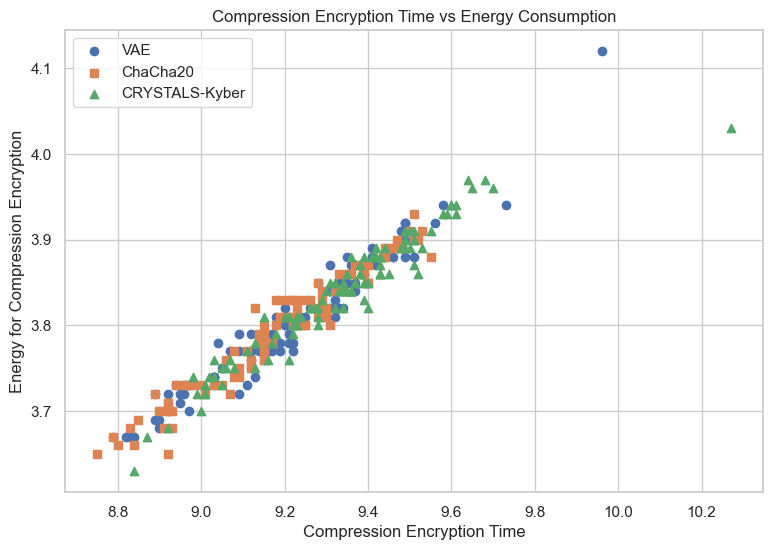

In [75]:
#import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

plt.figure(figsize=(9,6))

# Scatter plots
plt.scatter(
    vae_df['Compression_encryption_time'],
    vae_df['Energy_for_compression_encryption'],
    marker='o',
    label='VAE'
)

plt.scatter(
    chacha_df['Compression_encryption_time'],
    chacha_df['Energy_for_compression_encryption'],
    marker='s',
    label='ChaCha20'
)

plt.scatter(
    kyber_df['Compression_encryption_time'],
    kyber_df['Energy_for_compression_encryption'],
    marker='^',
    label='CRYSTALS-Kyber'
)

# Labels and styling
plt.title('Compression Encryption Time vs Energy Consumption')
plt.xlabel('Compression Encryption Time')
plt.ylabel('Energy for Compression Encryption')
plt.grid(True)
plt.legend()
plt.show()


#### In Transmission processing

In [73]:
# Group by Method and calculate mean and median
summary = df.groupby('Method')['Transmission_time'].agg(['mean', 'median']).reset_index()

summary

,Method,mean,median
0,CRYSTALS-Kyber,9.0515,9.050
1,ChaCha20,5.0261,5.030
2,VAE,5.0253,5.025


In [74]:
df

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Airtime_overhead,Energy_transmission_overhead,Energy_encryption_overhead
0,CRYSTALS-Kyber,0001q,1800,5,3,9.08,2.81,9.52,3.86,77.17,80.88,88.59,-2.03
2,CRYSTALS-Kyber,0002q,1800,5,5,9.04,2.69,8.92,3.68,77.17,80.08,78.15,-1.60
4,CRYSTALS-Kyber,0003q,1800,5,5,9.04,2.68,9.40,3.82,77.17,80.08,78.67,1.33
6,CRYSTALS-Kyber,0004q,1800,5,5,9.04,2.71,8.84,3.63,77.34,80.08,78.29,-4.97
8,CRYSTALS-Kyber,0005q,1801,5,5,9.04,2.72,9.16,3.76,77.26,80.08,80.13,2.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,VAE,0296v,1017,5,5,5.03,1.50,9.20,3.80,0.00,0.00,0.00,0.00
396,VAE,0297v,1016,5,5,5.03,1.50,9.42,3.87,0.00,0.00,0.00,0.00
397,VAE,0298v,1015,5,5,5.03,1.52,8.97,3.73,0.00,0.00,0.00,0.00
398,VAE,0299v,1016,5,5,5.03,1.52,9.03,3.74,0.00,0.00,0.00,0.00
